# Expectation Propagation from Scratch

This notebook implements expectation propagation (EP) for Gaussian
process classification using gaussx primitives. EP approximates
non-Gaussian likelihoods with local Gaussian "sites" in natural
parameter form, iterating a cavity-update-project loop until
convergence.

**What you'll learn:**

1. The EP algorithm for GP classification with a probit likelihood
2. How `GaussianSites` stores per-observation natural parameters
3. Computing cavity distributions and tilted moments
4. Damped site updates via `cvi_update_sites`
5. How sites produce block-diagonal precision via `sites_to_precision`

## 1. Background: EP for GP Classification

In GP classification we place a GP prior over a latent function
$f(\mathbf{x})$ and connect it to binary labels via a probit
likelihood:

$$p(y_i = 1 \mid f_i) = \Phi(f_i)$$

where $\Phi$ is the standard normal CDF. The posterior is:

$$p(\mathbf{f} \mid \mathbf{y}) \propto p(\mathbf{f}) \prod_{i=1}^N p(y_i \mid f_i)$$

This posterior is intractable because the probit factors break
conjugacy. EP approximates each likelihood factor with a Gaussian
*site* in natural parameter form:

$$\tilde{t}_i(f_i) \propto \exp\!\bigl(\eta_{1,i} f_i + \eta_{2,i} f_i^2\bigr)$$

where $\eta_{1,i}$ is the natural location and $\eta_{2,i} =
-\tfrac{1}{2}\lambda_i$ encodes the site precision $\lambda_i$.

The EP loop repeats three steps for each site $i$:

1. **Cavity**: Remove site $i$ from the current posterior to get the
   cavity distribution $q_{-i}(f_i)$.
2. **Tilt**: Form the tilted distribution
   $\hat{p}_i(f_i) \propto p(y_i \mid f_i)\, q_{-i}(f_i)$
   and compute its mean and variance.
3. **Update**: Project the tilted moments back to obtain new site
   natural parameters, then apply a damped update.

## 2. Setup and Data Generation

In [1]:
from __future__ import annotations

import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

Generate 1D binary classification data. The true decision boundary
comes from a latent function $f^*(x) = \sin(2x)$; labels are drawn
from $y_i \sim \text{Bernoulli}\bigl(\Phi(f^*(x_i))\bigr)$.

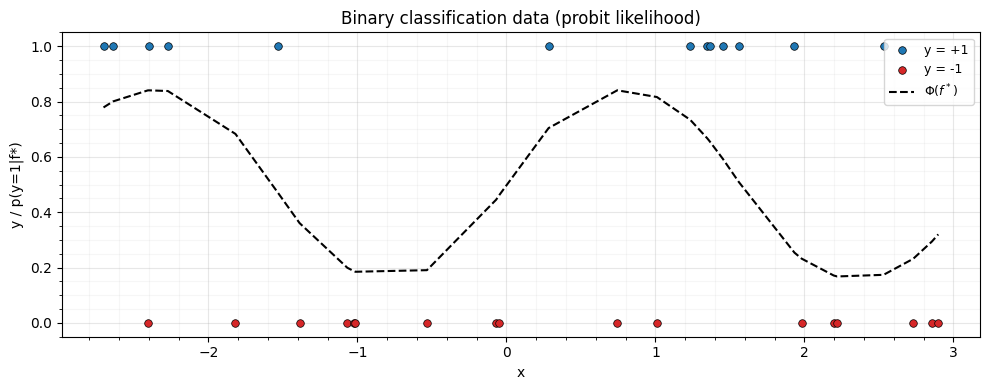

In [2]:
key = jax.random.PRNGKey(42)
N = 30

key, subkey = jax.random.split(key)
X = jnp.sort(jax.random.uniform(subkey, (N,), minval=-3.0, maxval=3.0))

f_true = jnp.sin(2.0 * X)

# Draw binary labels from probit likelihood
key, subkey = jax.random.split(key)
probs = jax.scipy.stats.norm.cdf(f_true)
y = jax.random.bernoulli(subkey, probs).astype(jnp.float64)
y_signed = 2.0 * y - 1.0  # convert to {-1, +1}

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(
    X[y == 1],
    y[y == 1],
    s=30,
    c="C0",
    edgecolors="k",
    linewidths=0.5,
    label="y = +1",
    zorder=5,
)
ax.scatter(
    X[y == 0],
    y[y == 0],
    s=30,
    c="C3",
    edgecolors="k",
    linewidths=0.5,
    label="y = -1",
    zorder=5,
)
ax.plot(
    X,
    jax.scipy.stats.norm.cdf(f_true),
    "k--",
    lw=1.5,
    label=r"$\Phi(f^*)$",
    zorder=4,
)
ax.set(xlabel="x", ylabel="y / p(y=1|f*)")
ax.legend(fontsize=9)
ax.set_title("Binary classification data (probit likelihood)")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## 3. GP Prior

We use an RBF (squared exponential) kernel:

$$k(x, x') = \sigma_f^2 \exp\!\Bigl(-\frac{(x - x')^2}{2\ell^2}\Bigr)$$

In [3]:
lengthscale = 1.0
variance = 1.0


def rbf_kernel(x1, x2, lengthscale=lengthscale, variance=variance):
    """Squared exponential kernel."""
    sq_dist = (x1[:, None] - x2[None, :]) ** 2
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale**2)


K_prior = rbf_kernel(X, X)
jitter = 1e-6
K_prior = K_prior + jitter * jnp.eye(N)
K_prior_op = lx.MatrixLinearOperator(K_prior)

prior_mean = jnp.zeros(N)

## 4. Initialize Gaussian Sites

`GaussianSites(nat1, nat2)` stores per-observation natural parameters.
For scalar EP ($d = 1$), `nat1` has shape `(N, 1)` and `nat2` has
shape `(N, 1, 1)`. We initialize both to zero, corresponding to an
uninformative (improper flat) site.

In [4]:
nat1_init = jnp.zeros((N, 1))
nat2_init = jnp.zeros((N, 1, 1))
sites = gaussx.GaussianSites(nat1=nat1_init, nat2=nat2_init)

print(f"Sites nat1 shape: {sites.nat1.shape}")
print(f"Sites nat2 shape: {sites.nat2.shape}")

Sites nat1 shape: (30, 1)
Sites nat2 shape: (30, 1, 1)


## 5. EP Helper Functions

### Tilted moments via Gauss-Hermite quadrature

The tilted distribution for site $i$ is:

$$\hat{p}_i(f_i) \propto p(y_i \mid f_i)\, q_{-i}(f_i)$$

where $q_{-i}(f_i) = \mathcal{N}(f_i \mid \mu_{-i}, \sigma_{-i}^2)$
is the cavity marginal. We need the mean and variance of $\hat{p}_i$.

Using the change of variable $f_i = \mu_{-i} + \sigma_{-i} z$ with
$z \sim \mathcal{N}(0, 1)$, we can compute the moments via
Gauss-Hermite quadrature using `gaussx.gauss_hermite_points`.

In [5]:
gh_points, gh_weights = gaussx.gauss_hermite_points(order=30, dim=1)
gh_z = gh_points[:, 0]  # (P,)

print(f"Gauss-Hermite: {gh_z.shape[0]} quadrature points")


def probit_log_lik(f, y_signed_i):
    """Log probit likelihood: log Phi(y_i * f_i)."""
    return jax.scipy.stats.norm.logcdf(y_signed_i * f)


def tilted_moments(cav_mean_i, cav_var_i, y_signed_i):
    """Compute mean and variance of the tilted distribution via GH quadrature.

    Args:
        cav_mean_i: Cavity mean (scalar).
        cav_var_i: Cavity variance (scalar, positive).
        y_signed_i: Signed label in {-1, +1}.

    Returns:
        (tilt_mean, tilt_var): Mean and variance of tilted distribution.
    """
    cav_std_i = jnp.sqrt(cav_var_i)

    # Transform quadrature points to cavity distribution
    f_pts = cav_mean_i + cav_std_i * gh_z  # (P,)

    # Log-weights: GH weights already account for the Gaussian measure,
    # so we only need the log-likelihood part
    log_lik = jax.vmap(lambda f: probit_log_lik(f, y_signed_i))(f_pts)  # (P,)

    # Normalize in log-space for numerical stability
    log_w = jnp.log(gh_weights) + log_lik
    log_Z = jax.scipy.special.logsumexp(log_w)
    w_normalized = jnp.exp(log_w - log_Z)

    # Tilted moments
    tilt_mean = jnp.sum(w_normalized * f_pts)
    tilt_var = jnp.sum(w_normalized * (f_pts - tilt_mean) ** 2)

    # Clamp variance to stay positive
    tilt_var = jnp.maximum(tilt_var, 1e-10)

    return tilt_mean, tilt_var

Gauss-Hermite: 30 quadrature points


## 6. The EP Loop

Each EP iteration:

1. **Posterior from prior + sites.** The site precision is
   $\Lambda_{\text{sites},i} = -2\,\eta_{2,i}$ (diagonal), and the
   posterior precision is $\Lambda = K^{-1} + \Lambda_{\text{sites}}$.

2. **Cavity.** For each $i$, remove site $i$:
   $\lambda_{-i} = \lambda_{\text{post},i} - \lambda_i$,
   $\eta_{1,-i} = \eta_{1,\text{post},i} - \eta_{1,i}$.

3. **Tilted moments.** Compute mean and variance of
   $p(y_i|f_i) q_{-i}(f_i)$ by quadrature.

4. **New site params.** Convert tilted moments to natural parameters
   using `newton_update`: the site precision is
   $\lambda_i^{\text{new}} = 1/v_{\text{tilt}} - 1/v_{-i}$
   and $\eta_{1,i}^{\text{new}} = m_{\text{tilt}}/v_{\text{tilt}} - m_{-i}/v_{-i}$.

5. **Damped update** via `cvi_update_sites`.

In [6]:
n_iterations = 15
rho = 0.5  # damping factor
log_z_history = []


def compute_posterior(prior_mean, K_prior_op, sites):
    """Compute the Gaussian posterior from prior + sites."""
    # Site precisions: -2 * nat2, shape (N, 1, 1) -> (N,)
    site_prec = -2.0 * sites.nat2[:, 0, 0]  # (N,)
    site_eta1 = sites.nat1[:, 0]  # (N,)

    # Posterior precision = K^{-1} + diag(site_prec)
    K_inv = gaussx.inv(K_prior_op).as_matrix()
    post_prec_mat = K_inv + jnp.diag(site_prec)
    post_prec_op = lx.MatrixLinearOperator(post_prec_mat)

    # Posterior covariance and mean
    post_cov_mat = gaussx.inv(post_prec_op).as_matrix()
    post_cov_op = lx.MatrixLinearOperator(post_cov_mat)

    # Posterior natural params: eta1_post = K^{-1} mu_prior + site_eta1
    prior_eta1 = gaussx.solve(K_prior_op, prior_mean)
    post_eta1 = prior_eta1 + site_eta1

    post_mean = post_cov_op.mv(post_eta1)

    return post_mean, post_cov_op, post_prec_mat


for iteration in range(n_iterations):
    # Step 1: compute current posterior
    post_mean, post_cov_op, post_prec_mat = compute_posterior(
        prior_mean, K_prior_op, sites
    )
    post_var = jnp.diag(post_cov_op.as_matrix())  # marginal variances

    # Current site params as flat vectors
    site_prec = -2.0 * sites.nat2[:, 0, 0]  # (N,)
    site_eta1 = sites.nat1[:, 0]  # (N,)

    # Step 2-4: for each site, compute cavity -> tilted -> new site
    new_nat1 = jnp.zeros(N)
    new_nat2 = jnp.zeros(N)
    log_z_sum = 0.0

    for i in range(N):
        # Cavity distribution (scalar shortcut)
        cav_prec_i = 1.0 / post_var[i] - site_prec[i]
        cav_prec_i = jnp.maximum(cav_prec_i, 1e-10)
        cav_var_i = 1.0 / cav_prec_i
        cav_mean_i = cav_var_i * (post_mean[i] / post_var[i] - site_eta1[i])

        # Tilted moments
        tilt_mean_i, tilt_var_i = tilted_moments(cav_mean_i, cav_var_i, y_signed[i])

        # New site from moment matching:
        # site_prec_new = 1/tilt_var - 1/cav_var
        # site_eta1_new = tilt_mean/tilt_var - cav_mean/cav_var
        site_prec_new_i = 1.0 / tilt_var_i - cav_prec_i
        site_prec_new_i = jnp.maximum(site_prec_new_i, 1e-10)
        site_eta1_new_i = tilt_mean_i / tilt_var_i - cav_mean_i * cav_prec_i

        new_nat1 = new_nat1.at[i].set(site_eta1_new_i)
        new_nat2 = new_nat2.at[i].set(-0.5 * site_prec_new_i)

        # Log normalizer for convergence monitoring
        z_i = jnp.exp(
            jax.scipy.special.logsumexp(
                jnp.log(gh_weights)
                + jax.vmap(lambda f, yi=y_signed[i]: probit_log_lik(f, yi))(
                    cav_mean_i + jnp.sqrt(cav_var_i) * gh_z
                )
            )
        )
        log_z_sum = log_z_sum + jnp.log(jnp.maximum(z_i, 1e-30))

    # Step 5: damped update via cvi_update_sites
    target_sites = gaussx.GaussianSites(
        nat1=new_nat1[:, None],
        nat2=new_nat2[:, None, None],
    )
    sites = gaussx.cvi_update_sites(sites, target_sites.nat1, target_sites.nat2, rho)

    log_z_history.append(float(log_z_sum))
    print(f"Iteration {iteration + 1:2d}: log Z sum = {log_z_sum:.4f}")

Iteration  1: log Z sum = 6.7737


Iteration  2: log Z sum = 8.3711


Iteration  3: log Z sum = 8.5472


Iteration  4: log Z sum = 8.5733


Iteration  5: log Z sum = 8.5774


...

Iteration 11: log Z sum = 8.5802


Iteration 12: log Z sum = 8.5804


Iteration 13: log Z sum = 8.5805


Iteration 14: log Z sum = 8.5805


Iteration 15: log Z sum = 8.5806


## 7. Convergence

The sum of log-normalizer terms $\sum_i \log Z_i$ should stabilize
as EP converges.

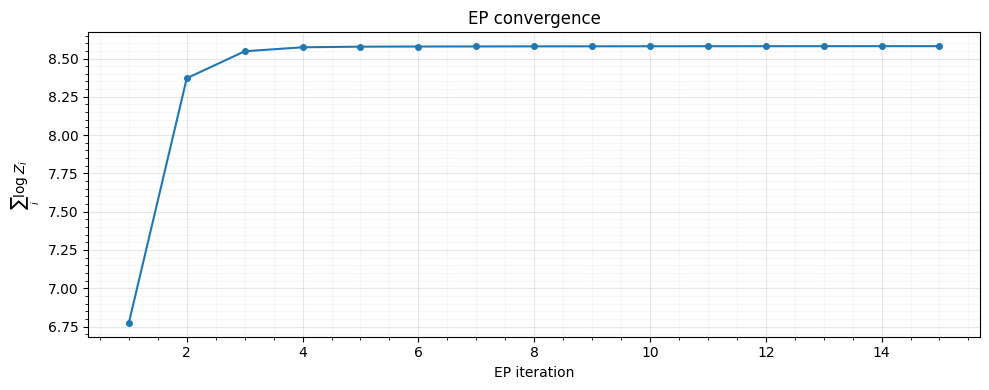

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, n_iterations + 1), log_z_history, "o-", markersize=4)
ax.set(xlabel="EP iteration", ylabel=r"$\sum_i \log Z_i$")
ax.set_title("EP convergence")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## 8. Posterior Predictions

Compute the final EP posterior and plot classification probabilities
$\Phi(\mu_i / \sqrt{1 + \sigma_i^2})$ with uncertainty bands.

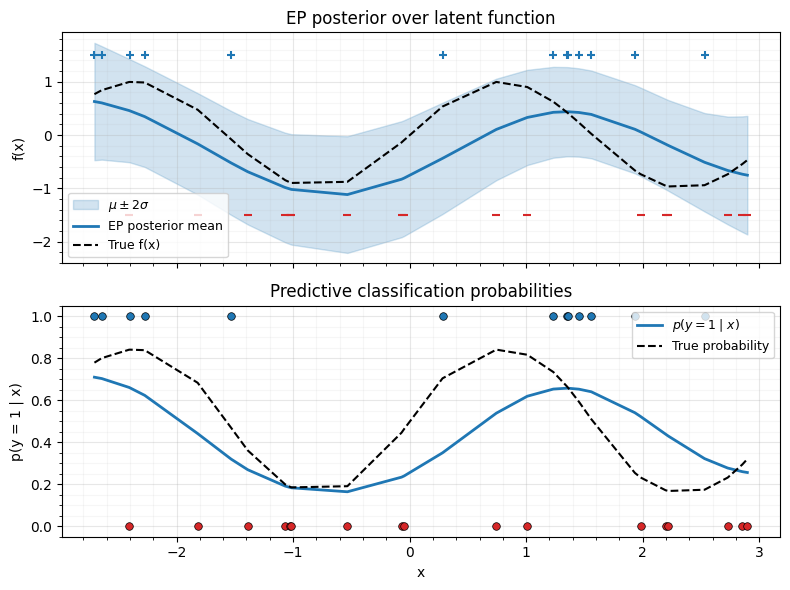

In [8]:
# Final posterior
post_mean, post_cov_op, post_prec_mat = compute_posterior(prior_mean, K_prior_op, sites)
post_var = jnp.diag(post_cov_op.as_matrix())
post_std = jnp.sqrt(post_var)

# Classification probabilities (integrating out latent f)
# p(y=1|x) = E_q[Phi(f)] = Phi(mu / sqrt(1 + sigma^2))
pred_probs = jax.scipy.stats.norm.cdf(post_mean / jnp.sqrt(1.0 + post_var))

# Confidence bands on latent function
f_upper = post_mean + 2.0 * post_std
f_lower = post_mean - 2.0 * post_std

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Top: latent function posterior
ax = axes[0]
ax.fill_between(X, f_lower, f_upper, alpha=0.2, color="C0", label=r"$\mu \pm 2\sigma$")
ax.plot(X, post_mean, "C0-", lw=2, label="EP posterior mean", zorder=3)
ax.plot(X, f_true, "k--", lw=1.5, label="True f(x)", zorder=4)
ax.scatter(
    X[y == 1],
    jnp.ones_like(X[y == 1]) * 1.5,
    c="C0",
    marker="+",
    s=40,
    zorder=5,
)
ax.scatter(
    X[y == 0],
    jnp.ones_like(X[y == 0]) * -1.5,
    c="C3",
    marker="_",
    s=40,
    zorder=5,
)
ax.set(ylabel="f(x)")
ax.legend(fontsize=9)
ax.set_title("EP posterior over latent function")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

# Bottom: predictive probabilities
ax = axes[1]
ax.plot(X, pred_probs, "C0-", lw=2, label=r"$p(y=1 \mid x)$", zorder=3)
ax.plot(
    X,
    jax.scipy.stats.norm.cdf(f_true),
    "k--",
    lw=1.5,
    label="True probability",
    zorder=4,
)
ax.scatter(
    X[y == 1],
    y[y == 1],
    s=30,
    c="C0",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
)
ax.scatter(
    X[y == 0],
    y[y == 0],
    s=30,
    c="C3",
    edgecolors="k",
    linewidths=0.5,
    zorder=5,
)
ax.set(xlabel="x", ylabel="p(y = 1 | x)")
ax.legend(fontsize=9)
ax.set_title("Predictive classification probabilities")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()

plt.tight_layout()
plt.show()

## 9. Precision Structure via `sites_to_precision`

The site natural parameters form a diagonal precision contribution.
`sites_to_precision` wraps these into a `BlockTriDiag` operator with
zero sub-diagonals --- a block-diagonal structure. In a state-space
GP model, combining this with the prior's block-tridiagonal precision
yields a full block-tridiagonal posterior precision, enabling
$O(Nd^3)$ inference.

In [9]:
site_precision = gaussx.sites_to_precision(sites)
print(f"Type: {type(site_precision).__name__}")
print(f"Diagonal blocks shape: {site_precision.diagonal.shape}")
print(f"Sub-diagonal blocks shape: {site_precision.sub_diagonal.shape}")

# Verify sub-diagonals are zero (block-diagonal structure)
print(f"Sub-diagonal norm: {jnp.linalg.norm(site_precision.sub_diagonal):.2e}")

Type: BlockTriDiag
Diagonal blocks shape: (30, 1, 1)
Sub-diagonal blocks shape: (29, 1, 1)
Sub-diagonal norm: 0.00e+00


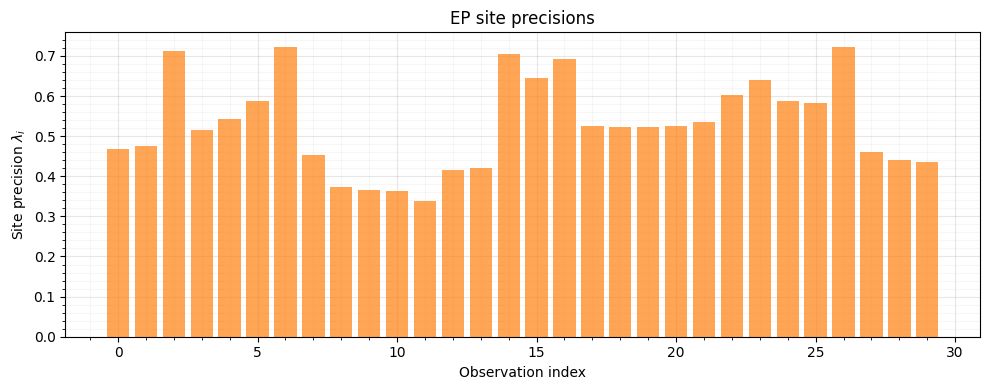

In [10]:
# Visualize the site precisions (diagonal entries)
site_prec_values = -2.0 * sites.nat2[:, 0, 0]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(N), site_prec_values, color="C1", alpha=0.7)
ax.set(xlabel="Observation index", ylabel=r"Site precision $\lambda_i$")
ax.set_title("EP site precisions")
ax.set_axisbelow(True)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

Sites near the decision boundary have higher precision --- EP
concentrates its approximation effort where the likelihood is most
informative.

## 10. Using `cavity_distribution` and `newton_update`

For completeness, let us verify the gaussx API functions on the final
posterior. `cavity_distribution` removes a site from the full
posterior, and `newton_update` converts derivatives into natural
parameters.

In [11]:
# Pick site i = N // 2 (near the middle of the domain)
i = N // 2

# Wrap site i's natural params as lineax operators for cavity_distribution
site_nat1_i = sites.nat1[i, 0]  # scalar
site_nat2_i = -2.0 * sites.nat2[i, 0, 0]  # site precision scalar

# Build full-size vectors/operators for site i
site_nat1_vec = jnp.zeros(N).at[i].set(site_nat1_i)
site_nat2_mat = jnp.diag(jnp.zeros(N).at[i].set(site_nat2_i))
site_nat2_op = lx.MatrixLinearOperator(site_nat2_mat)

cav_mean, cav_cov = gaussx.cavity_distribution(
    post_mean, post_cov_op, site_nat1_vec, site_nat2_op
)

print(f"Cavity mean at i={i}: {cav_mean[i]:.4f}")
print(f"Cavity var  at i={i}: {jnp.diag(cav_cov.as_matrix())[i]:.4f}")

Cavity mean at i=15: 0.3418
Cavity var  at i=15: 0.2653


In [12]:
# newton_update: convert Hessian of log-likelihood to site natural params
# For probit, at the posterior mean:
f_i = post_mean[i]
yi = y_signed[i]

# Derivatives of log Phi(y*f) w.r.t. f
pdf_val = jax.scipy.stats.norm.pdf(yi * f_i)
cdf_val = jax.scipy.stats.norm.cdf(yi * f_i)
ratio = pdf_val / jnp.maximum(cdf_val, 1e-10)
jacobian_i = yi * ratio
hessian_i = -(ratio**2 + yi * f_i * ratio)

# newton_update expects arrays
mean_arr = jnp.array([f_i])
jac_arr = jnp.array([jacobian_i])
hess_arr = jnp.array([[hessian_i]])

nat1_newton, nat2_newton = gaussx.newton_update(mean_arr, jac_arr, hess_arr)
print(f"Newton nat1: {nat1_newton[0]:.4f}")
print(f"Newton nat2 (= -hessian): {nat2_newton[0, 0]:.4f}")

Newton nat1: -0.7967
Newton nat2 (= -hessian): 0.6590


## Summary

This notebook demonstrated EP for GP classification from scratch using
gaussx building blocks:

| gaussx API | Role in EP |
|---|---|
| `GaussianSites(nat1, nat2)` | Store per-site natural parameters |
| `cvi_update_sites(sites, ...)` | Damped natural parameter update |
| `sites_to_precision(sites)` | Convert sites to `BlockTriDiag` precision |
| `cavity_distribution(...)` | Remove a site from the posterior |
| `newton_update(mean, jac, hess)` | Derivatives to natural parameters |
| `gauss_hermite_points(order, dim)` | Quadrature for tilted moments |
| `BlockTriDiag` | Structured block-tridiagonal operator |

Key takeaways:

- EP iterates cavity-tilt-project to approximate non-Gaussian
  likelihoods with local Gaussian sites.
- The natural parameterization
  ($\eta_1 = \Lambda \mu$, $\eta_2 = -\tfrac{1}{2}\Lambda$) makes
  site addition and removal simple additions in parameter space.
- `sites_to_precision` produces a `BlockTriDiag` that can be combined
  with state-space GP priors for scalable temporal inference.
- Damping (`rho < 1`) in `cvi_update_sites` is essential for EP
  stability.